<p align="center">
  <img src="img/logoitqv1.png" width="270" style="margin-right: 20px;">
</p>
<div style="clear:both;"></div>

##  3_1_4_var_cuantitativas
#  July 13, 2026

<p align="center">
  <img src="img/python_logo.png" width="220" style="margin-left: 20px;">
</p>
<div style="clear:both;"></div>

*Elvis David Pachacama* 

*Ian Mijail Morales Patiño*

0.1 01PAO26-26 - Variables cuantitativas

<br>
<a href="https://github.com/Ian-183/practica-machine-learning">https://github.com/Ian-183/practica-machine-learningb</a>

In [1]:
# Creación aleatoria de datos
import numpy as np
X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5,-28, -50, 60, -100, -10, -11, 13, 19, 1, 9])
print(X)


[   0.5   23.     0.3    4.5    0.3    0.5  -28.   -50.    60.  -100.
  -10.   -11.    13.    19.     1.     9. ]


In [10]:
!pip install scipy scikit-learn
# Medidas de tendencia central
from scipy import stats
media = np.mean(X)
mediana = np.median(X)
moda , _ = stats.mode(X)
print('media: ', media)
print('mediana: ', mediana)
print('moda :', moda)

media:  3.4644999999999997
mediana:  3.2
moda : [5.  3.  1.4 0.2]


In [3]:
# Medidas de posición
import numpy as np
import matplotlib.pyplot as plt
Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)
RIC = Q3 - Q1
lim_inf = Q1 - 1.5*RIC
lim_sup = Q3 + 1.5*RIC
print('RIC :', RIC)
print('limite inferior :', lim_inf)
print('limite superior :', lim_sup)


RIC : 20.25
limite inferior : -40.625
limite superior : 40.375


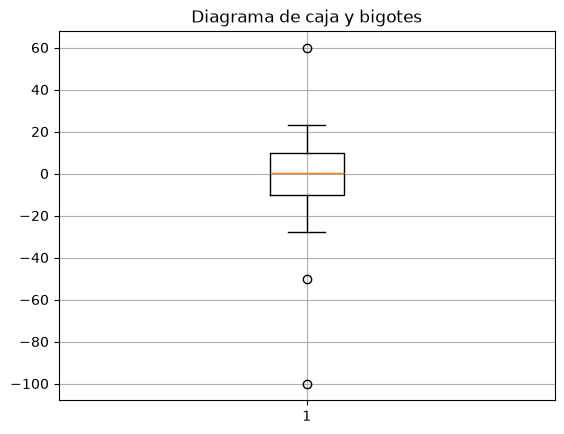

In [4]:
 # Dibuja el diagrama de box and whiskers y determina visualmente el número de outliers
plt.boxplot(X)
plt.grid()
plt.title("Diagrama de caja y bigotes")
plt.show()

In [5]:
# Medidas de dispersión
desvest = np.std(X)
print('Desviación típica: ', desvest)
print('Varianza: ', desvest**2)


Desviación típica:  33.521242681880096
Varianza:  1123.6737109375


In [6]:
 # Medidas de distribución
asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html
print('Asimetría ', np.round(asimetria, 4))
print('Curtosis ', np.round(curtosis, 4))
if curtosis>0:
  print('Distribución Leptocúrtica')
elif curtosis<0:
  print('Distribución Platicúrtica')
else:
  print('Distribución Mesocúrtica')


Asimetría  -1.1302
Curtosis  2.2858
Distribución Leptocúrtica


In [7]:
# Cargar el set de datos de Iris
from sklearn import datasets
from pprint import pprint
iris = datasets.load_iris()
pprint(iris)
X = iris.data
y = iris.target
# ¿Qué tipo de asimetría se observa en la variable "longitud del pétalo"?
#???
# ¿A qué tipo de distribución se ajusta la variable "ancho del sépalo", según␣su curtosis?
#???

{'DESCR': '.. _iris_dataset:\n'
          '\n'
          'Iris plants dataset\n'
          '--------------------\n'
          '\n'
          '**Data Set Characteristics:**\n'
          '\n'
          ':Number of Instances: 150 (50 in each of three classes)\n'
          ':Number of Attributes: 4 numeric, predictive attributes and the '
          'class\n'
          ':Attribute Information:\n'
          '    - sepal length in cm\n'
          '    - sepal width in cm\n'
          '    - petal length in cm\n'
          '    - petal width in cm\n'
          '    - class:\n'
          '            - Iris-Setosa\n'
          '            - Iris-Versicolour\n'
          '            - Iris-Virginica\n'
          '\n'
          ':Summary Statistics:\n'
          '\n'
          '============== ==== ==== ======= ===== ====================\n'
          '                Min  Max   Mean    SD   Class Correlation\n'
          '============== ==== ==== ======= ===== ====================\n'
          '

In [8]:
from scipy import stats
import numpy as np

# Cargar variables
X = iris.data
y = iris.target

# 1. Asimetría de "longitud del pétalo" (columna 2)
asimetria_petalo = stats.skew(X[:, 2])
print(f'Asimetría (longitud del pétalo): {asimetria_petalo:.4f}')

if asimetria_petalo < 0:
    print('La variable presenta una asimetría negativa (sesgo hacia la izquierda).')
elif asimetria_petalo > 0:
    print('La variable presenta una asimetría positiva (sesgo hacia la derecha).')
else:
    print('La variable es simétrica.')

# 2. Curtosis de "ancho del sépalo" (columna 1)
curtosis_sepalo = stats.kurtosis(X[:, 1], fisher=True)
print(f'Curtosis (ancho del sépalo): {curtosis_sepalo:.4f}')

if curtosis_sepalo > 0:
    print('La distribución es leptocúrtica.')
elif curtosis_sepalo < 0:
    print('La distribución es platicúrtica.')
else:
    print('La distribución es mesocúrtica.')

Asimetría (longitud del pétalo): -0.2721
La variable presenta una asimetría negativa (sesgo hacia la izquierda).
Curtosis (ancho del sépalo): 0.1810
La distribución es leptocúrtica.


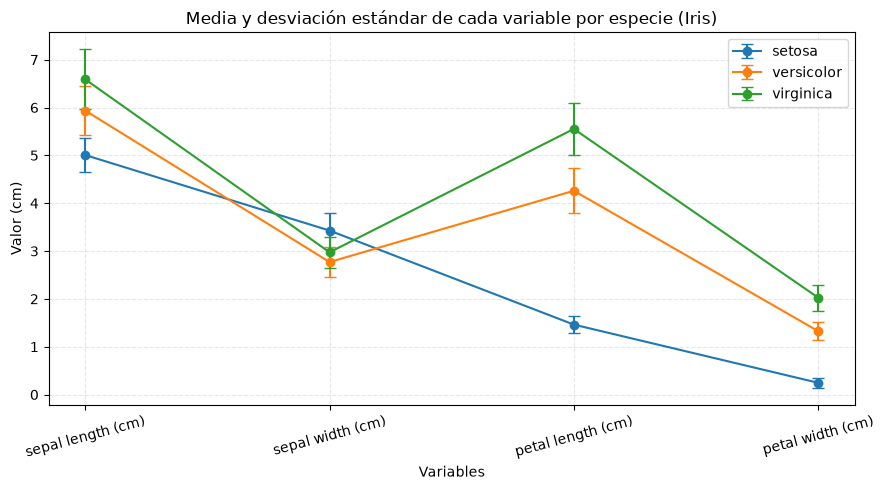

In [9]:
# EJERCICIO EXTRA SOBRE EL DATASET DE IRIS
# Extraer la media y la desviación típica de cada variable en función de la␣clase y representarlo en un gráfico (plt.errorbar)
import matplotlib.pyplot as plt
import numpy as np

# Nombres de variables y especies
feature_names = iris.feature_names
target_names = iris.target_names

plt.figure(figsize=(9, 5))

# Calcular media y desviación estándar por cada clase (especie)
for i, target_name in enumerate(target_names):
    X_clase = X[y == i]
    
    medias = np.mean(X_clase, axis=0)
    desviaciones = np.std(X_clase, axis=0)
    
    # Representar con barras de error
    plt.errorbar(
        feature_names, 
        medias, 
        yerr=desviaciones, 
        label=target_name, 
        fmt='-o', 
        capsize=4
    )

# Formato del gráfico
plt.title('Media y desviación estándar de cada variable por especie (Iris)')
plt.xlabel('Variables')
plt.ylabel('Valor (cm)')
plt.xticks(rotation=15)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()